# 实验六之二：LMCC 字符级 RNN 语言模型

本 Notebook 对应《RNN 实验》3.1 节：从零开始实现循环神经网络，并在 *The Time Machine* 字符数据集上训练字符级语言模型。

实验与课件保持一致：

- 数据：字符级语料，`batch_size=32`，`num_steps=35`；
- 模型：手动定义参数、隐藏状态和单时间步 RNN 计算，隐藏单元数为 `512`；
- 训练：交叉熵损失、随机梯度下降、梯度裁剪，共训练 `500` 轮；
- 评价：困惑度（perplexity）与每秒处理字符数；
- 对照：分别使用顺序分区和随机采样训练，并从 `time traveller`、`traveller` 前缀生成文本。

课件示例依赖旧版 `d2l==0.17.0`。为避免旧依赖在新环境中冲突，本 Notebook 直接实现实验需要的数据迭代器、训练工具和绘图函数，不需要安装 `d2l`。在 LMCC 新建 Notebook 后复制本文件并 **Run All** 即可。

## 1. 导入依赖并设置实验参数

默认参数就是课件要求的正式实验参数。`LAB6_FAST_DEV_RUN=1` 仅供本地检查代码链路，不会在 LMCC 默认运行时启用。

In [1]:
%matplotlib inline

import math
import os
import random
import re
import time
import urllib.request
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F

SEED = 42
FAST_DEV_RUN = os.environ.get("LAB6_FAST_DEV_RUN", "0") == "1"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 4 if FAST_DEV_RUN else 32
NUM_STEPS = 10 if FAST_DEV_RUN else 35
NUM_HIDDENS = 32 if FAST_DEV_RUN else 512
NUM_EPOCHS = 2 if FAST_DEV_RUN else 500
LEARNING_RATE = 1.0
MAX_TOKENS = 1000 if FAST_DEV_RUN else 10000

random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("设备:", DEVICE)
print("快速冒烟测试:", FAST_DEV_RUN)
print({
    "batch_size": BATCH_SIZE,
    "num_steps": NUM_STEPS,
    "num_hiddens": NUM_HIDDENS,
    "num_epochs": NUM_EPOCHS,
})

PyTorch: 2.2.2
设备: cpu
快速冒烟测试: False
{'batch_size': 32, 'num_steps': 35, 'num_hiddens': 512, 'num_epochs': 500}


## 2. 读取并预处理 Time Machine 字符数据

先把非字母字符归一化为空格并转成小写，再按字符切分，建立“字符 ↔ 整数索引”的词表。正式运行会优先读取 `data/timemachine.txt` 或 `../data/timemachine.txt`；本地不存在时才从 D2L 数据源下载。

In [2]:
TIME_MACHINE_URLS = [
    "https://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt",
    "http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt",
]


def locate_or_download_time_machine():
    candidates = [Path("data/timemachine.txt"), Path("../data/timemachine.txt")]
    for candidate in candidates:
        if candidate.is_file() and candidate.stat().st_size > 10000:
            return candidate.resolve()

    target = candidates[0]
    target.parent.mkdir(parents=True, exist_ok=True)
    last_error = None
    for url in TIME_MACHINE_URLS:
        try:
            with urllib.request.urlopen(url, timeout=30) as response:
                content = response.read()
            if len(content) <= 10000:
                raise ValueError("下载到的语料文件异常短")
            target.write_bytes(content)
            return target.resolve()
        except Exception as exc:
            last_error = exc

    raise RuntimeError(
        "无法读取 Time Machine 数据。请把 timemachine.txt 放到 data/ 目录后重试。"
    ) from last_error


def read_time_machine():
    if FAST_DEV_RUN:
        # 只用于验证数据→模型→反向传播→预测的完整链路。
        sentence = (
            "the time traveller for so it will be convenient to speak of him was expounding "
            "a recondite matter to us his grey eyes shone and twinkled "
        )
        return [sentence * 12]

    data_path = locate_or_download_time_machine()
    with data_path.open("r", encoding="utf-8") as file:
        lines = file.readlines()
    print("数据文件:", data_path)
    return [re.sub("[^A-Za-z]+", " ", line).strip().lower() for line in lines]


lines = read_time_machine()
print("文本行数:", len(lines))
print("示例:", lines[0][:100])

数据文件: /Users/bob.li/Code/DL-ZJU/lab6-2/data/timemachine.txt
文本行数: 3221
示例: the time machine by h g wells


In [3]:
def tokenize(lines, token="word"):
    if token == "word":
        return [line.split() for line in lines]
    if token == "char":
        return [list(line) for line in lines]
    raise ValueError(f"未知分词方式: {token}")


def count_corpus(tokens):
    if not tokens:
        return Counter()
    if isinstance(tokens[0], (list, tuple)):
        tokens = [token for line in tokens for token in line]
    return Counter(tokens)


class Vocab:
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        tokens = [] if tokens is None else tokens
        reserved_tokens = [] if reserved_tokens is None else reserved_tokens
        counter = count_corpus(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda item: item[1], reverse=True)
        self.idx_to_token = ["<unk>"] + list(reserved_tokens)
        self.token_to_idx = {token: index for index, token in enumerate(self.idx_to_token)}
        for token, freq in self.token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self[token] for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):
        return 0


def load_corpus_time_machine(max_tokens=-1):
    tokens = tokenize(read_time_machine(), "char")
    vocab = Vocab(tokens)
    corpus = [vocab[token] for line in tokens for token in line]
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab


def seq_data_iter_random(corpus, batch_size, num_steps):
    corpus = corpus[random.randint(0, num_steps - 1):]
    num_subsequences = (len(corpus) - 1) // num_steps
    initial_indices = list(range(0, num_subsequences * num_steps, num_steps))
    random.shuffle(initial_indices)

    def data(position):
        return corpus[position:position + num_steps]

    num_batches = num_subsequences // batch_size
    for i in range(0, batch_size * num_batches, batch_size):
        batch_indices = initial_indices[i:i + batch_size]
        X = [data(j) for j in batch_indices]
        Y = [data(j + 1) for j in batch_indices]
        yield torch.tensor(X), torch.tensor(Y)


def seq_data_iter_sequential(corpus, batch_size, num_steps):
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset:offset + num_tokens])
    Ys = torch.tensor(corpus[offset + 1:offset + 1 + num_tokens])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_steps * num_batches, num_steps):
        yield Xs[:, i:i + num_steps], Ys[:, i:i + num_steps]


class SeqDataLoader:
    def __init__(self, batch_size, num_steps, use_random_iter, max_tokens):
        self.corpus, self.vocab = load_corpus_time_machine(max_tokens)
        self.batch_size = batch_size
        self.num_steps = num_steps
        self.data_iter_fn = seq_data_iter_random if use_random_iter else seq_data_iter_sequential

    def __iter__(self):
        return self.data_iter_fn(self.corpus, self.batch_size, self.num_steps)


def load_data_time_machine(batch_size, num_steps, use_random_iter=False, max_tokens=10000):
    data_iter = SeqDataLoader(batch_size, num_steps, use_random_iter, max_tokens)
    return data_iter, data_iter.vocab

In [4]:
train_iter, vocab = load_data_time_machine(
    BATCH_SIZE, NUM_STEPS, use_random_iter=False, max_tokens=MAX_TOKENS
)
X, Y = next(iter(train_iter))

assert X.shape == Y.shape == (BATCH_SIZE, NUM_STEPS)
assert len(vocab) > 1
print("词表大小:", len(vocab))
print("X/Y 形状:", tuple(X.shape), tuple(Y.shape))
print("X 第一行:", "".join(vocab.to_tokens(X[0].tolist())))
print("Y 第一行:", "".join(vocab.to_tokens(Y[0].tolist())))

数据文件: /Users/bob.li/Code/DL-ZJU/lab6-2/data/timemachine.txt
词表大小: 28
X/Y 形状: (32, 35) (32, 35)
X 第一行: e machine by h g wellsithe time tra
Y 第一行:  machine by h g wellsithe time trav


## 3. 从零定义循环神经网络

对每个时间步 $t$，模型计算

$$H_t = \tanh(X_tW_{xh}+H_{t-1}W_{hh}+b_h),$$

$$Y_t = H_tW_{hq}+b_q.$$

输入字符先转成 one-hot 向量。`RNNModelScratch` 负责保存参数、初始化隐藏状态并包装前向计算。

In [5]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01

    W_xh = normal((num_inputs, num_hiddens))
    W_hh = normal((num_hiddens, num_hiddens))
    b_h = torch.zeros(num_hiddens, device=device)
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params


def init_rnn_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),)


def rnn(inputs, state, params):
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X_t in inputs:
        H = torch.tanh(X_t @ W_xh + H @ W_hh + b_h)
        Y_t = H @ W_hq + b_q
        outputs.append(Y_t)
    return torch.cat(outputs, dim=0), (H,)


class RNNModelScratch:
    def __init__(self, vocab_size, num_hiddens, device, get_params_fn, init_state_fn, forward_fn):
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.params = get_params_fn(vocab_size, num_hiddens, device)
        self.init_state = init_state_fn
        self.forward_fn = forward_fn

    def __call__(self, X, state):
        inputs = F.one_hot(X.T, self.vocab_size).to(torch.float32)
        return self.forward_fn(inputs, state, self.params)

    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)

## 4. 检查输出与隐藏状态形状

模型把每个时间步、每个样本的输出拼在一起，因此输出形状应为 `(num_steps × batch_size, vocab_size)`；隐藏状态形状应为 `(batch_size, num_hiddens)`。

In [6]:
net = RNNModelScratch(
    len(vocab), NUM_HIDDENS, DEVICE, get_params, init_rnn_state, rnn
)
state = net.begin_state(batch_size=X.shape[0], device=DEVICE)
Y_hat, new_state = net(X.to(DEVICE), state)

expected_output_shape = (X.numel(), len(vocab))
assert Y_hat.shape == expected_output_shape
assert len(new_state) == 1
assert new_state[0].shape == (X.shape[0], NUM_HIDDENS)
print("输出形状:", tuple(Y_hat.shape))
print("隐藏状态形状:", tuple(new_state[0].shape))

输出形状: (1120, 28)
隐藏状态形状: (32, 512)


## 5. 定义字符预测函数

先用前缀中的字符逐步更新隐藏状态，这一阶段称为预热（warm-up）；再把每一步概率最大的字符作为下一步输入，连续生成指定数量的新字符。未训练模型的输出没有语言意义，这是预期现象。

In [7]:
def predict_ch8(prefix, num_preds, net, vocab, device):
    if not prefix:
        raise ValueError("prefix 不能为空")

    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]

    def get_input():
        return torch.tensor([outputs[-1]], device=device).reshape((1, 1))

    for character in prefix[1:]:
        _, state = net(get_input(), state)
        outputs.append(vocab[character])

    for _ in range(num_preds):
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).item()))

    return "".join(vocab.to_tokens(outputs))


untrained_text = predict_ch8("time traveller", 10, net, vocab, DEVICE)
assert untrained_text.startswith("time traveller")
assert len(untrained_text) == len("time traveller") + 10
print("训练前预测:", untrained_text)

训练前预测: time travellertrtrtrtrtr


## 6. 梯度裁剪与训练函数

梯度的全局 $L_2$ 范数超过阈值 `theta` 时，将所有梯度按同一比例缩小，避免梯度爆炸。训练损失转换为困惑度 $\exp(\text{cross-entropy})$；困惑度越低，模型对下一个字符越确定。

In [8]:
def grad_clipping(net, theta):
    if isinstance(net, nn.Module):
        params = [param for param in net.parameters() if param.requires_grad]
    else:
        params = net.params
    params_with_grad = [param for param in params if param.grad is not None]
    norm = torch.sqrt(sum(torch.sum(param.grad ** 2) for param in params_with_grad))
    if norm > theta:
        for param in params_with_grad:
            param.grad[:] *= theta / norm


def sgd(params, learning_rate, batch_size):
    with torch.no_grad():
        for param in params:
            param -= learning_rate * param.grad / batch_size
            param.grad.zero_()


class Accumulator:
    def __init__(self, size):
        self.data = [0.0] * size

    def add(self, *args):
        self.data = [value + float(item) for value, item in zip(self.data, args)]

    def __getitem__(self, index):
        return self.data[index]


def train_epoch_ch8(net, train_iter, loss_fn, updater, device, use_random_iter):
    state = None
    start = time.time()
    metric = Accumulator(2)  # 损失总和、词元总数

    for X_batch, Y_batch in train_iter:
        if state is None or use_random_iter:
            state = net.begin_state(batch_size=X_batch.shape[0], device=device)
        else:
            if isinstance(state, torch.Tensor):
                state.detach_()
            else:
                for value in state:
                    value.detach_()

        labels = Y_batch.T.reshape(-1).to(device)
        X_batch = X_batch.to(device)
        predictions, state = net(X_batch, state)
        loss = loss_fn(predictions, labels).mean()

        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad(set_to_none=True)
            loss.backward()
            grad_clipping(net, 1.0)
            updater.step()
        else:
            loss.backward()
            grad_clipping(net, 1.0)
            updater(batch_size=1)

        metric.add(loss * labels.numel(), labels.numel())

    elapsed = max(time.time() - start, 1e-9)
    perplexity = math.exp(min(metric[0] / metric[1], 20))
    speed = metric[1] / elapsed
    return perplexity, speed


def train_ch8(net, train_iter, vocab, learning_rate, num_epochs, device, use_random_iter=False):
    loss_fn = nn.CrossEntropyLoss()
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), learning_rate)
    else:
        updater = lambda batch_size: sgd(net.params, learning_rate, batch_size)

    history = []
    report_every = 1 if FAST_DEV_RUN else 10
    for epoch in range(1, num_epochs + 1):
        perplexity, speed = train_epoch_ch8(
            net, train_iter, loss_fn, updater, device, use_random_iter
        )
        history.append((epoch, perplexity))
        if epoch % report_every == 0 or epoch == num_epochs:
            sample = predict_ch8("time traveller", 50, net, vocab, device)
            print(f"Epoch {epoch:03d}/{num_epochs} | 困惑度 {perplexity:.1f} | {speed:.1f} 词元/秒")
            print(sample)

    print(f"最终困惑度 {perplexity:.1f}, {speed:.1f} 词元/秒, {device}")
    print(predict_ch8("time traveller", 50, net, vocab, device))
    print(predict_ch8("traveller", 50, net, vocab, device))
    return history, perplexity, speed


def plot_history(history, title):
    epochs, perplexities = zip(*history)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, perplexities, label="train")
    plt.xlabel("epoch")
    plt.ylabel("perplexity")
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7. 使用顺序分区训练

顺序分区中，相邻小批量在原始序列上连续，因此每轮开始时初始化隐藏状态，后续批次复用并分离上一批次的隐藏状态。

Epoch 010/500 | 困惑度 13.6 | 33714.6 词元/秒
time traveller the the the the the the the the the the the the t
Epoch 020/500 | 困惑度 10.6 | 57080.3 词元/秒
time traveller the the the the the the the the the the the the t
Epoch 030/500 | 困惑度 9.6 | 55755.7 词元/秒
time travellere the the the the the the the the the the the the 
Epoch 040/500 | 困惑度 8.9 | 36950.1 词元/秒
time travellere the the the the the the the the the the the the 
Epoch 050/500 | 困惑度 8.7 | 47717.0 词元/秒
time travellere the the the the the the the the the the the the 
Epoch 060/500 | 困惑度 8.2 | 47170.3 词元/秒
time travellere the the the the the the the the the the the the 
Epoch 070/500 | 困惑度 8.0 | 55110.0 词元/秒
time travellere the the the the the the the the the the the the 
Epoch 080/500 | 困惑度 7.7 | 43698.1 词元/秒
time traveller and the the the the the the the the the the the t
Epoch 090/500 | 困惑度 7.6 | 40028.8 词元/秒
time traveller and the this the this the this the this the this 
Epoch 100/500 | 困惑度 7.2 | 48810.8 词元/秒
time traveller andithe 

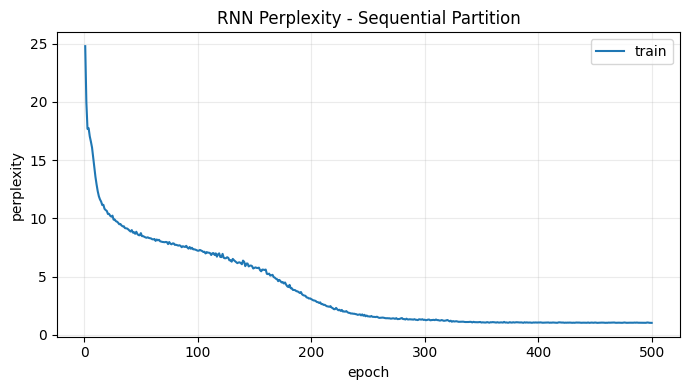

In [9]:
net_sequential = RNNModelScratch(
    len(vocab), NUM_HIDDENS, DEVICE, get_params, init_rnn_state, rnn
)
sequential_history, sequential_perplexity, sequential_speed = train_ch8(
    net_sequential, train_iter, vocab, LEARNING_RATE, NUM_EPOCHS, DEVICE
)
plot_history(sequential_history, "RNN Perplexity - Sequential Partition")

## 8. 使用随机采样训练

随机采样打乱固定长度的子序列，相邻批次通常不连续，因此每个小批量都重新初始化隐藏状态。下面重新创建模型，避免沿用顺序分区已经训练过的参数。

数据文件: /Users/bob.li/Code/DL-ZJU/lab6-2/data/timemachine.txt
Epoch 010/500 | 困惑度 13.5 | 56568.5 词元/秒
time traveller the the the the the the the the the the the the t
Epoch 020/500 | 困惑度 10.7 | 66008.9 词元/秒
time travellere the the the the the the the the the the the the 
Epoch 030/500 | 困惑度 9.7 | 50673.3 词元/秒
time travellere the the the the the the the the the the the the 
Epoch 040/500 | 困惑度 9.1 | 53104.2 词元/秒
time travellere the the the the the the the the the the the the 
Epoch 050/500 | 困惑度 8.6 | 27884.0 词元/秒
time travellere the the the the the the the the the the the the 
Epoch 060/500 | 困惑度 8.3 | 42310.2 词元/秒
time traveller and the the the the the the the the the the the t
Epoch 070/500 | 困惑度 8.1 | 40828.0 词元/秒
time traveller and the the the the the the the the the the the t
Epoch 080/500 | 困惑度 8.0 | 42830.6 词元/秒
time traveller and the the the the the the the the the the the t
Epoch 090/500 | 困惑度 7.7 | 67157.0 词元/秒
time traveller and the the the the the the the the the the the t
Ep

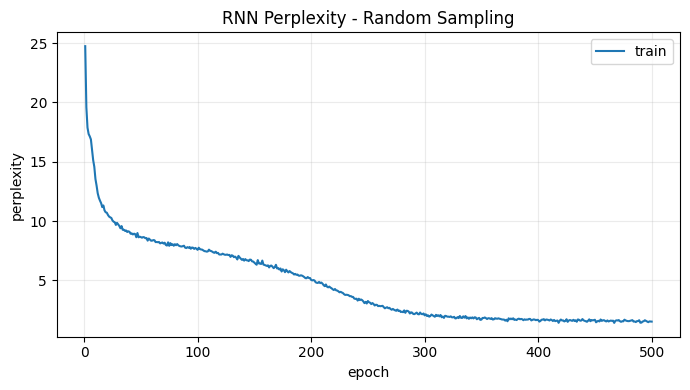

In [10]:
random_train_iter, random_vocab = load_data_time_machine(
    BATCH_SIZE, NUM_STEPS, use_random_iter=True, max_tokens=MAX_TOKENS
)
assert random_vocab.idx_to_token == vocab.idx_to_token

net_random = RNNModelScratch(
    len(vocab), NUM_HIDDENS, DEVICE, get_params, init_rnn_state, rnn
)
random_history, random_perplexity, random_speed = train_ch8(
    net_random,
    random_train_iter,
    vocab,
    LEARNING_RATE,
    NUM_EPOCHS,
    DEVICE,
    use_random_iter=True,
)
plot_history(random_history, "RNN Perplexity - Random Sampling")

## 9. 实验结果检查与报告记录

下面检查课件要求的关键配置、两种采样方式和最终预测。正式 LMCC 运行结束后，可将两条困惑度曲线、最终困惑度、运行速度及两组生成文本放入实验报告。快速模式只证明代码链路可运行，不代表正式实验结果。

In [11]:
assert len(sequential_history) == NUM_EPOCHS
assert len(random_history) == NUM_EPOCHS
assert math.isfinite(sequential_perplexity) and sequential_perplexity > 0
assert math.isfinite(random_perplexity) and random_perplexity > 0
assert predict_ch8("time traveller", 10, net_sequential, vocab, DEVICE).startswith("time traveller")
assert predict_ch8("time traveller", 10, net_random, vocab, DEVICE).startswith("time traveller")

if not FAST_DEV_RUN:
    assert BATCH_SIZE == 32
    assert NUM_STEPS == 35
    assert NUM_HIDDENS == 512
    assert NUM_EPOCHS == 500
    assert MAX_TOKENS == 10000

print("✅ Lab 6-2 全部检查通过")
print({
    "mode": "fast-dev" if FAST_DEV_RUN else "full-lmcc",
    "sequential_perplexity": sequential_perplexity,
    "random_perplexity": random_perplexity,
    "sequential_tokens_per_second": sequential_speed,
    "random_tokens_per_second": random_speed,
})

✅ Lab 6-2 全部检查通过
{'mode': 'full-lmcc', 'sequential_perplexity': 1.0244508451096181, 'random_perplexity': 1.5184848715093016, 'sequential_tokens_per_second': 43422.00512546766, 'random_tokens_per_second': 54251.85298962196}


## 10.一些拓展

加入温度：
0.3：非常保守，倾向选择最高概率字符，容易重复；
0.7：稳定但有一定变化，通常比较合适；
1.0：直接按照模型原始概率采样；
1.5：更随机、更有创意，也更容易出现乱码式单词。

In [12]:
def sample_ch8(
    prefix,
    num_preds,
    net,
    vocab,
    device,
    temperature=1.0,
    top_k=None,
):
    if not prefix:
        raise ValueError("prefix 不能为空")

    unknown = [char for char in prefix if char not in vocab.token_to_idx]
    if unknown:
        raise ValueError(f"前缀包含词表外字符：{unknown}")

    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]

    def get_input():
        return torch.tensor(
            [[outputs[-1]]],
            device=device,
        )

    with torch.no_grad():
        # 用前缀预热隐藏状态
        for character in prefix[1:]:
            _, state = net(get_input(), state)
            outputs.append(vocab[character])

        # 按概率随机生成后续字符
        for _ in range(num_preds):
            logits, state = net(get_input(), state)
            scores = logits[-1].clone()

            # 不生成 <unk>
            scores[vocab.unk] = float("-inf")
            scores = scores / temperature

            if top_k is not None:
                k = min(top_k, len(vocab))
                top_values, top_indices = torch.topk(scores, k)
                probabilities = torch.softmax(top_values, dim=0)
                sampled_position = torch.multinomial(probabilities, 1)
                next_index = int(top_indices[sampled_position].item())
            else:
                probabilities = torch.softmax(scores, dim=0)
                next_index = int(torch.multinomial(probabilities, 1).item())

            outputs.append(next_index)

    return "".join(vocab.to_tokens(outputs))

In [27]:
print(sample_ch8(
    prefix="the time traveller",
    num_preds=800,       # 新生成 800 个字符
    net=net_sequential,
    vocab=vocab,
    device=DEVICE,
    temperature=0.1,
    top_k=8,
))

the time traveller for so it will be convenient to speak of himwas expounding a recondite matter to us his grey eyes shone andtwinkled and his usually pale face was flushed and animated thefire burned brightly and the soft radiance of the incandescentlights in the lilies of silver caughrar foleche sbuled ant you taicknewur h hr nsten all has sack avl yor at thingth se ino as ad our dow you kn s moves intermittently in one direction along thelatter from the beginning to the end of our livesthat said a very young man making spasmodic efforts to relighthis cigar over the lamp that very clear indeednow it is very remarkable that this is so extensively overlookedcontinued trepsone move ane thed if fime you conas ou thetranthof cis seale it to breactn schelahaleng ho d he lekled ano a midtr veryan sarelyer he rad
